In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 # transform image data

In [4]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

In [5]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for x, y in test_dataloader :
    print(f"Shape of X [N, C, H, W]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
# more general accelterator detection than "torch.cuda.is_available()"
print(f"Using {device} device")

class NeuralNetwork(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
    
    def forward(self, x) :
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
# SGD is Stochastic Gradient Descent.
# it uses random mini-batches of data instrad of full dataset. -> Stochastic
# faster than full batch gradient descent and use less memory.
# but it can be less stable.

In [11]:
def train(dataloader, model, loss_fn, optimizer) :
    size = len(dataloader.dataset)
    model.train()
    for batch, (x, y) in enumerate(dataloader) :
        X, y = x.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0 :
            loss, current = loss.item(), (batch+1) * len(x)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [12]:
def test(dataloader, model, loss_fn) :
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad() :
        for X, y in dataloader :
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss = loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct = size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [13]:
epochs = 5
for t in range(epochs) :
    print(f"Epoch {t+1}\n-------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done")

Epoch 1
-------------
loss: 2.298970  [   64/60000]
loss: 2.285807  [ 6464/60000]
loss: 2.265810  [12864/60000]
loss: 2.271925  [19264/60000]
loss: 2.247168  [25664/60000]
loss: 2.219157  [32064/60000]
loss: 2.236486  [38464/60000]
loss: 2.201507  [44864/60000]
loss: 2.200495  [51264/60000]
loss: 2.180148  [57664/60000]
Test Error: 
 Accuracy: 1000000.0%, Avg loss: 0.014004 

Epoch 2
-------------
loss: 2.174052  [   64/60000]
loss: 2.164427  [ 6464/60000]
loss: 2.104564  [12864/60000]
loss: 2.135580  [19264/60000]
loss: 2.080928  [25664/60000]
loss: 2.020785  [32064/60000]
loss: 2.065418  [38464/60000]
loss: 1.984152  [44864/60000]
loss: 1.991593  [51264/60000]
loss: 1.939512  [57664/60000]
Test Error: 
 Accuracy: 1000000.0%, Avg loss: 0.012545 

Epoch 3
-------------
loss: 1.952437  [   64/60000]
loss: 1.924561  [ 6464/60000]
loss: 1.801201  [12864/60000]
loss: 1.862040  [19264/60000]
loss: 1.750976  [25664/60000]
loss: 1.695612  [32064/60000]
loss: 1.733279  [38464/60000]
loss: 1.62

In [14]:
torch.save(model.state_dict(), "model.pth")
print("Saved Pytorch Model State to model.pth")

Saved Pytorch Model State to model.pth


In [15]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

It is Sneaker


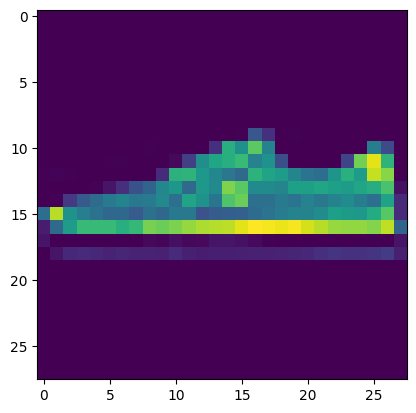

In [33]:
import matplotlib.pyplot as plt

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

images, labels = next(iter(train_dataloader))
image = images[torch.randint(0, batch_size, (1,)).item()]
plt.imshow(image.squeeze(0))

pred = model(image)
print(f"It is {classes[torch.argmax(pred, dim=1)]}")